# ANALISIS (histograma, boxplot, heatmap)

In [1]:
import os
print(os.getcwd())

/home/ismael/Documentos/Finanza_flutter/IA_HUGO/data_set1


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("synthetic_personal_finance_dataset.csv")
df.head()

,user_id,age,gender,education_level,employment_status,job_title,monthly_income_usd,monthly_expenses_usd,savings_usd,has_loan,loan_type,loan_amount_usd,loan_term_months,monthly_emi_usd,loan_interest_rate_pct,debt_to_income_ratio,credit_score,savings_to_income_ratio,region,record_date
0,U00001,56,Female,High School,Self-employed,Salesperson,3531.69,1182.59,367655.03,No,NaN,0.00,0,0.00,0.00,0.00,430,8.68,Other,2024-01-09
1,U00002,19,Female,PhD,Employed,Salesperson,3531.73,2367.99,260869.10,Yes,Education,146323.34,36,4953.50,13.33,1.40,543,6.16,North America,2022-02-13
2,U00003,20,Female,Master,Employed,Teacher,2799.49,1003.91,230921.21,No,NaN,0.00,0,0.00,0.00,0.00,754,6.87,Africa,2022-05-12
3,U00004,25,Male,PhD,Employed,Manager,5894.88,4440.12,304815.51,Yes,Business,93242.37,24,4926.57,23.93,0.84,461,4.31,Europe,2023-10-02
4,U00005,53,Female,PhD,Employed,Student,5128.93,4137.61,461509.48,No,NaN,0.00,0,0.00,0.00,0.00,516,7.50,Africa,2021-08-07


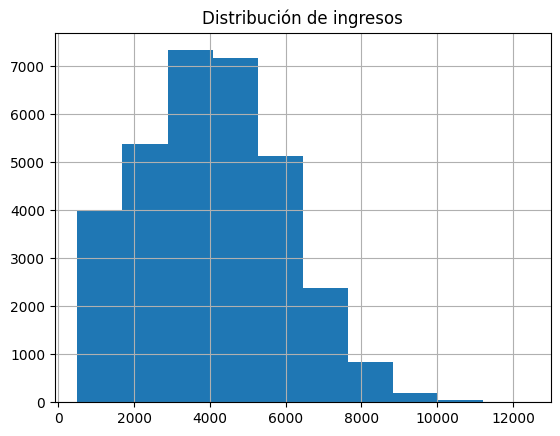

In [3]:
df['monthly_income_usd'].hist()
plt.title("Distribución de ingresos")
plt.show()

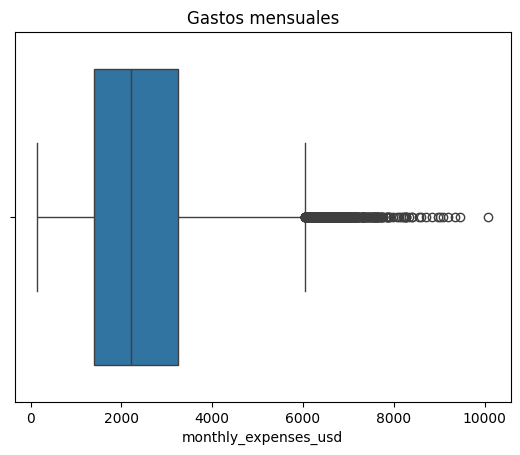

In [4]:
sns.boxplot(x=df['monthly_expenses_usd'])
plt.title("Gastos mensuales")
plt.show()

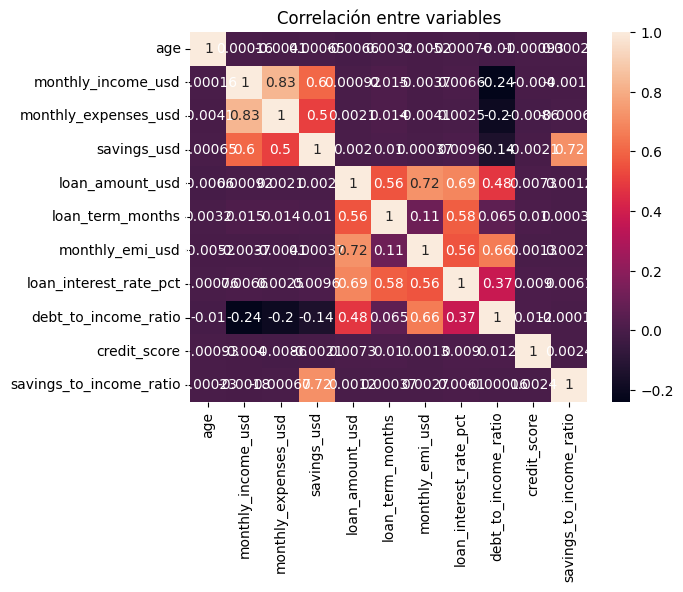

In [5]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)
plt.title("Correlación entre variables")
plt.show()

Se realizó un análisis exploratorio del dataset financiero para identificar patrones en los ingresos, gastos y otras variables económicas.

El histograma muestra la distribución de los ingresos, mientras que el boxplot permite identificar valores atípicos en los gastos.

Finalmente, el mapa de calor permite observar la relación entre variables como ingresos, gastos y ahorro.

# PRUEBAS DEL MODELO 

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# seleccionar variables
X = df[['monthly_income_usd', 'savings_usd', 'credit_score']]
y = df['monthly_expenses_usd']

# dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# modelo
model = LinearRegression()
model.fit(X_train, y_train)

# predicción
y_pred = model.predict(X_test)

# error
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 605.2177900287052


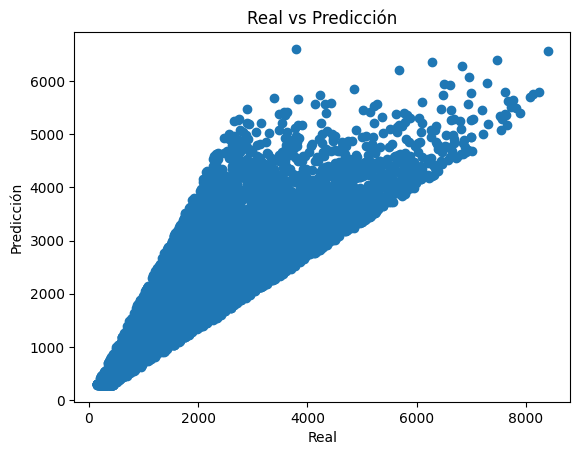

In [7]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Real")
plt.ylabel("Predicción")
plt.title("Real vs Predicción")
plt.show()